Task_4
Lab_5

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)


In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
corr_matrix = df.corr()
corr_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


In [14]:

X_reduced = df.drop(['AveBedrms', 'Longitude'], axis=1)

print("features", X_reduced.shape[1])

features 6


In [15]:
from sklearn.feature_selection import VarianceThreshold

# إزالة المزايا التي لها تباين أقل من 0.01
selector = VarianceThreshold(threshold=1.0)
original_count = df.shape[1]
X_reduced = selector.fit_transform(df)

print("the feature before filtering:", original_count)
print("the feature after filtering:", X_reduced.shape[1])

the feature before filtering: 8
the feature after filtering: 7


In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print( pca.explained_variance_ratio_)

[0.28216523 0.20504825]


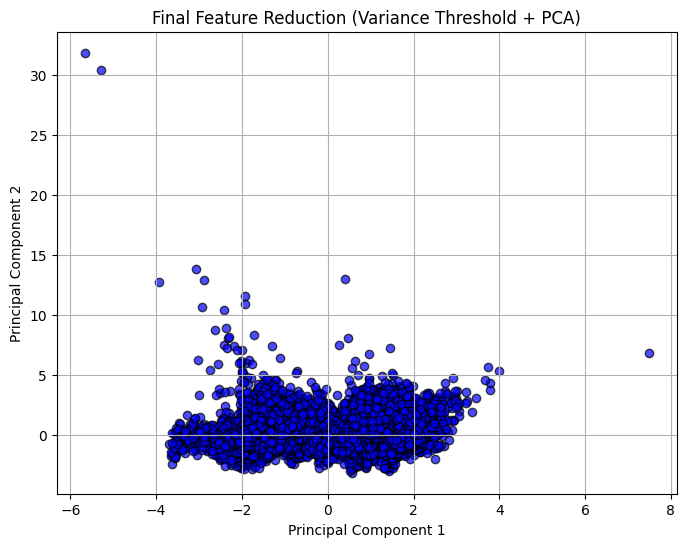

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, c='blue', edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Final Feature Reduction (Variance Threshold + PCA)')
plt.grid(True)
plt.show()

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print( pca.explained_variance_ratio_)

[0.28216523 0.20504825 0.17143573]


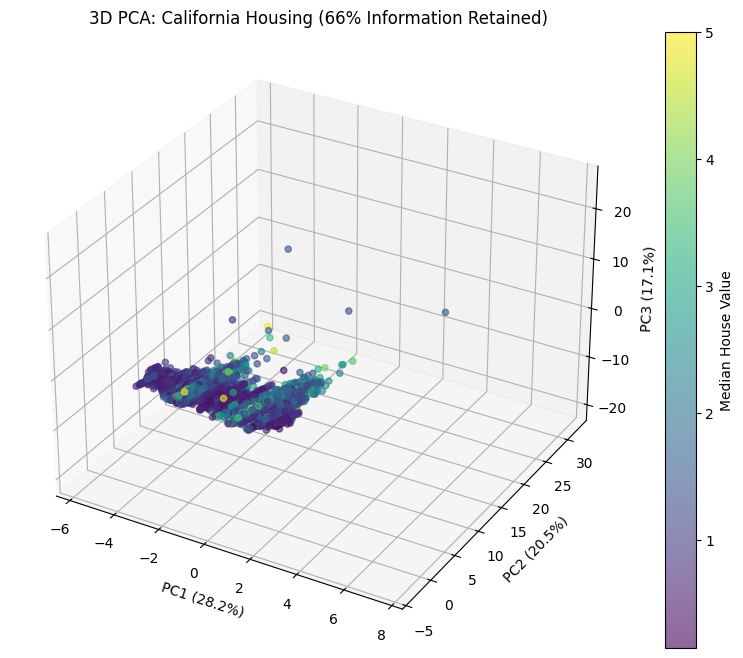

In [25]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. إنشاء شكل الرسم وتحديد أنه ثلاثي الأبعاد
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. رسم النقاط باستخدام الثلاثة مكونات (PC1, PC2, PC3)
# ملحوظة: X_pca هنا يجب أن يكون ناتج PCA(n_components=3)
scatter = ax.scatter(X_pca[:, 0], 
                     X_pca[:, 1], 
                     X_pca[:, 2], 
                     c=housing.target, # تلوين النقاط بناءً على سعر البيت
                     cmap='viridis', 
                     alpha=0.6)

# 3. تسمية المحاور بنسب التباين التي استخرجتِها
ax.set_xlabel(f'PC1 (28.2%)')
ax.set_ylabel(f'PC2 (20.5%)')
ax.set_zlabel(f'PC3 (17.1%)')

# 4. إضافة عنوان وشريط الألوان
plt.title('3D PCA: California Housing (66% Information Retained)')
fig.colorbar(scatter, ax=ax, label='Median House Value')

plt.show()